<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_14_1_drift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 14: Wrapping Up**  

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 14 Material

* **Part 14.1: Model Drift** [[Video]]() [[Notebook]](t81_558_class_14_1_drift.ipynb)
* Part 14.2: Dealing with Bias [[Video]]() [[Notebook]](t81_558_class_14_2_bias.ipynb)
* Part 14.3: Other Deep Learning Frameworks [[Video]]() [[Notebook]](t81_558_class_14_3_frameworks.ipynb)
* Part 14.4: Deploying a PyTorch Neural Network [[Video]]() [[Notebook]](t81_558_class_14_4_deploy.ipynb)
* Part 14.5: The Future of AI [[Video]]() [[Notebook]](t81_558_class_14_5_new_tech.ipynb)

# Google CoLab Instructions

The following code checks that Google CoLab is running and sets up the correct hardware settings for PyTorch.

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 2.5)
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: not using Google CoLab


Using device: mps


# Part 14.1: Model Drift

A trained model captures the patterns in the data it was trained on. But the world does not hold still. Customer behavior shifts, sensors age, fraud tactics evolve, and the language people use changes. When the data a model sees in production drifts away from the data it learned from, its accuracy quietly erodes. This phenomenon is called **model drift**, and it is one of the main reasons a model that performed well at launch can become unreliable months later, often without any error or warning.

Model drift is a *deployment* problem rather than a *training* problem. Nothing about the model changes; the model is exactly as it was on the day it was trained. What changes is the data flowing into it. Because the degradation is gradual and silent, drift is easy to miss until a real-world failure exposes it. Guarding against it requires treating a deployed model as something to be monitored and maintained, not as a finished artifact.

This section defines the main kinds of drift, shows through simulation how drift degrades accuracy over time, and demonstrates how statistical monitoring can raise an alarm. We close with the strategies teams use to keep models healthy in production.

## Types of Drift

Drift comes in a few distinct forms, and the distinction matters because they are detected and handled differently.

* **Data drift** (also called covariate shift) means the distribution of the *inputs* changes: `P(x)` is no longer what it was. A camera model deployed to a new region sees different lighting; a credit model sees applicants with different income distributions. The relationship between inputs and outputs may be unchanged, but the model is now being asked about regions of input space it saw rarely during training.

* **Concept drift** means the *relationship* between inputs and outputs changes: `P(y | x)` shifts. The same input should now produce a different answer. Spam filters face this constantly, as spammers deliberately change what a "legitimate-looking" message contains. Concept drift is the most dangerous kind because the inputs can look completely normal while the correct answers have moved.

* **Label drift** (prior shift) means the distribution of the *outputs* changes: `P(y)` shifts, such as a surge in the base rate of fraud during a holiday season.

The crucial practical consequence is detectability. Data drift can be spotted by watching the inputs alone, with no labels required. Concept drift, by contrast, can leave the inputs looking perfectly normal, so it often can only be caught once true outcomes arrive and reveal that accuracy has fallen.

## Simulating Concept Drift

To make drift concrete, we simulate a classifier deployed over twelve months while the underlying concept slowly rotates. We train the model once on month-zero data and then, without retraining, evaluate it each month as the true decision boundary gradually turns. Because the model is frozen while the concept moves, we expect its accuracy to decay.

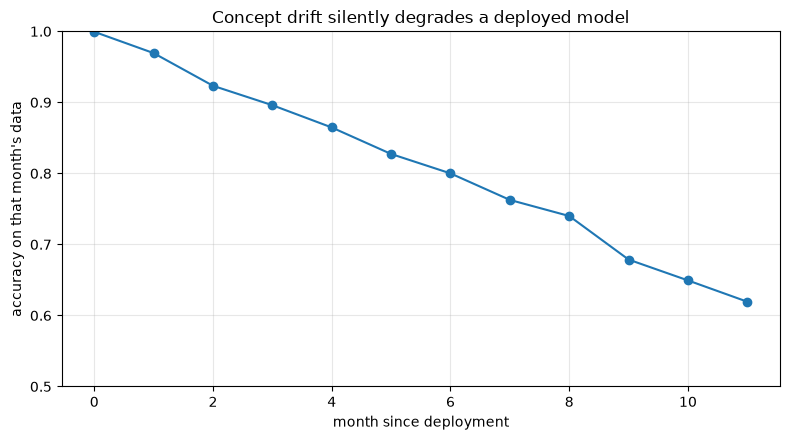

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)


def sample(n, angle):
    """Two features; the decision boundary is oriented by `angle` (the concept)."""
    X = np.random.randn(n, 2).astype(np.float32)
    boundary = np.cos(angle) * X[:, 0] + np.sin(angle) * X[:, 1]
    y = (boundary > 0).astype(np.int64)
    return X, y


# Train once on month 0 (angle = 0).
X0, y0 = sample(3000, angle=0.0)
model = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 2))
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()
Xt, yt = torch.tensor(X0), torch.tensor(y0)
for _ in range(400):
    opt.zero_grad()
    loss_fn(model(Xt), yt).backward()
    opt.step()

# Deploy for 12 months; the concept (boundary orientation) drifts gradually.
angles = np.linspace(0.0, 1.2, 12)
accuracy = []
for angle in angles:
    Xm, ym = sample(1500, angle)
    with torch.no_grad():
        pred = model(torch.tensor(Xm)).argmax(1).numpy()
    accuracy.append((pred == ym).mean())

plt.figure(figsize=(8, 4.5))
plt.plot(range(12), accuracy, "o-")
plt.xlabel("month since deployment")
plt.ylabel("accuracy on that month's data")
plt.title("Concept drift silently degrades a deployed model")
plt.ylim(0.5, 1.0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The accuracy curve slides downward month after month even though the model itself never changed. Nothing in the code broke; the model is simply answering an old question while the world has moved on to a new one. In a real system this decline might go unnoticed until it caused a visible business problem, which is exactly why drift must be monitored deliberately rather than assumed away.

## Detecting Drift

There are two complementary ways to watch for drift. The first is **performance monitoring**: track the model's accuracy (or other metrics) on fresh data as the true labels arrive. This catches every kind of drift, including concept drift, but it is delayed, because you must wait for ground-truth labels, which in many applications take days or weeks to materialize.

The second is **input monitoring**: compare the distribution of incoming features against the training distribution, with no labels required. A statistical test such as the Kolmogorov-Smirnov (KS) test flags when a feature's distribution has moved. This gives an early, label-free warning, but only for *data* drift; pure concept drift, where the inputs look unchanged, is invisible to it. The demonstration below shows a feature whose distribution shifts over time and how the KS statistic rises to detect it.

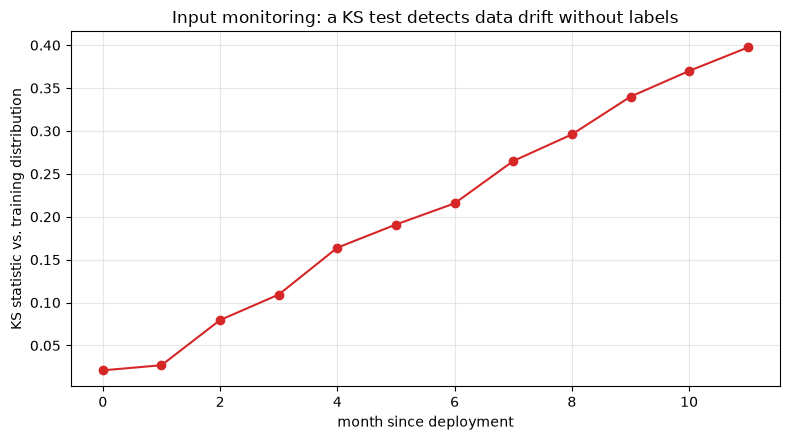

month 0 KS p-value: 0.767  (no drift detected)
month 11 KS p-value: 0.00000  (drift clearly detected)


In [3]:
from scipy.stats import ks_2samp

# A feature whose distribution drifts: its mean creeps upward each month.
reference = np.random.randn(3000)          # distribution seen during training
ks_stat, ks_pvalue = [], []
for month in range(12):
    current = np.random.randn(1500) + 0.10 * month    # data drift
    result = ks_2samp(reference, current)
    ks_stat.append(result.statistic)
    ks_pvalue.append(result.pvalue)

plt.figure(figsize=(8, 4.5))
plt.plot(range(12), ks_stat, "o-", color="tab:red")
plt.xlabel("month since deployment")
plt.ylabel("KS statistic vs. training distribution")
plt.title("Input monitoring: a KS test detects data drift without labels")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"month 0 KS p-value: {ks_pvalue[0]:.3f}  (no drift detected)")
print(f"month 11 KS p-value: {ks_pvalue[11]:.5f}  (drift clearly detected)")

The KS statistic climbs steadily as the feature drifts, and by the final month the p-value is tiny, a confident, automatic alarm raised without a single label. This is the appeal of input monitoring: it can warn you that something has changed before the accuracy numbers, which depend on slow-arriving labels, have caught up. The limitation, as noted, is that it sees only data drift; concept drift like the rotating boundary above would slip past a KS test on the inputs and could only be caught by watching performance.

## Responding to Drift

Once drift is detected, the standard response is to **retrain** the model on recent data so it reflects the current world. Teams operationalize this in several ways. The simplest is *scheduled retraining* on a fixed cadence, retraining nightly or weekly regardless of measured drift. More efficient is *triggered retraining*, where a monitoring system retrains only when a drift alarm fires, saving compute when the world is stable. For fast-moving problems, *online learning* updates the model continuously as new labeled data arrives.

Whatever the cadence, the essential shift in mindset is that a deployed model is not a finished product but a component that requires ongoing monitoring and maintenance. A robust production system pairs the model with dashboards that track both its performance and its input distributions, alerting when either moves. The techniques here connect directly to the deployment concerns in [Part 14.4](t81_558_class_14_4_deploy.ipynb), and drift is closely related to fairness: a model can also drift into treating groups unequally, which is the subject of the next section, [Dealing with Bias](t81_558_class_14_2_bias.ipynb).